### Figure 4 of *Grund & Ritter (2020)*, GJI

This Jupyter Notebook allows to reproduce **Fig. 4** of our GJI paper:

> _**Grund, M. & Ritter, J. R. R. (2020)**_, Shear-wave splitting beneath Fennoscandia — evidence for dipping structures and laterally varying multilayer anisotropy, *Geophysical Journal International*, https://doi.org/10.1093/gji/ggaa388.


Feel free to modify or play around with the different parameters!

**PyGMT and GMT requirements history:**
* 2020-07-23 (original version): PyGMT [0.1.0](https://www.pygmt.org/v0.1.0/index.html) & GMT >= [6.0.0](https://docs.generic-mapping-tools.org/6.0/)
* 2024-06-01: PyGMT [0.12.0](https://www.pygmt.org/v0.12.0/index.html) & GMT >= [6.3.0](https://docs.generic-mapping-tools.org/6.3/)
* 2025-08-26: PyGMT [0.16.0](https://www.pygmt.org/v0.16.0/index.html) & GMT >= [6.4.0](https://docs.generic-mapping-tools.org/6.4/)
* 2026-08-27 (last modified): PyGMT [0.19.0](https://www.pygmt.org/v0.19.0/index.html) & GMT >= [6.5.0](https://docs.generic-mapping-tools.org/6.5/)

**Additional required packages:**
* pandas
* numpy

**Author**: 
* Michael Grund ([@michaelgrund](https://github.com/michaelgrund))

In [1]:
import pygmt
import numpy as np
import pandas as pd
import io

# define parameters for plotting
pygmt.config(MAP_GRID_PEN_PRIMARY = '0.3p,dimgrey',
             MAP_ANNOT_OFFSET_PRIMARY = '5p',
             MAP_ANNOT_OFFSET_SECONDARY = '5p',
             MAP_ANNOT_OBLIQUE = '30',
             FONT_ANNOT_PRIMARY = '8p,Helvetica', 
             FONT_LABEL = '8p',
             MAP_FRAME_TYPE = 'fancy',
             MAP_FRAME_WIDTH = '2p',
             MAP_FRAME_PEN = '1.1p',
             MAP_TICK_LENGTH_PRIMARY = '5p',
             MAP_LABEL_OFFSET = '5.5p'
            )

Create a new pygmt figure object.

In [2]:
fig = pygmt.Figure()

Next we define the map content and plot an elevation grid as background using `fig.grdimage()`.
* Here we can directly access the elevation grid via PyGMT by defining the desired resolution (`'@earth_relief_01m'`, corresponds to ETOPO1 data). Afterwards the required grid of the area is automatically extracted based on the defined region limits (`region = [3.5, 36.5, 54, 71.5]`). The first time you access an elevation grid file it will be downloaded from the GMT server and stored under your GMT user directory. Then the grid file is read from there. For further details see [here (PyGMT docs)](https://www.pygmt.org/latest/api/generated/pygmt.datasets.load_earth_relief.html#pygmt.datasets.load_earth_relief) or [here (GMT docs)](https://www.generic-mapping-tools.org/remote-datasets/).
* We use an Albers conic equal-area projection via `projection = 'l20/60/16/80/1:10000000'`.
* The background is colored by using the colormap `gray.cpt` and shading is set to `True`.

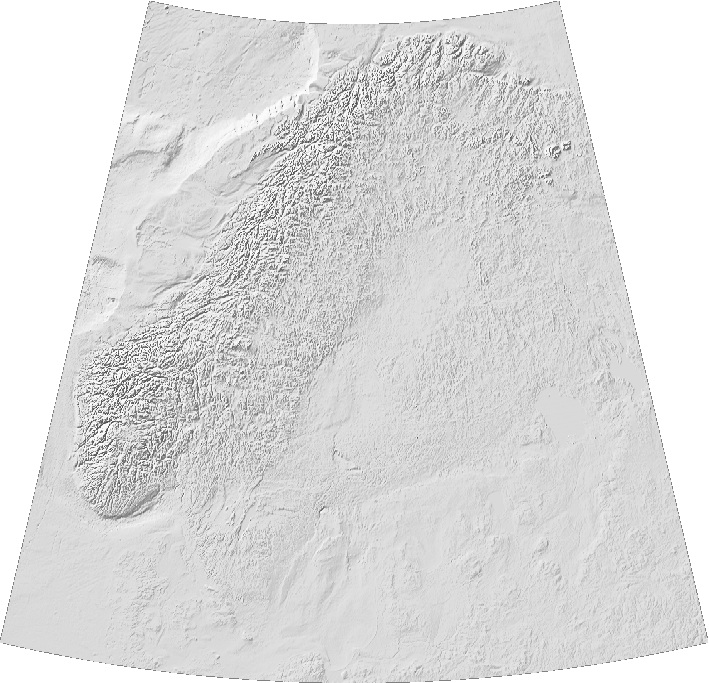

In [3]:
fig.grdimage('@earth_relief_01m',  
             region = [3.5, 36.5, 54, 71.5], 
             projection = 'l20/60/16/80/1:10000000',
             shading = True,
             cmap = 'gray.cpt'
            )

# set the resolution of the intermediate steps figures that are displayed in the notebook below 
# (to reduce notebook file size), in the end the figure is shown and saved in png format in high 
# resolution
dpifig = 100
fig.show(dpi = dpifig)

Now let's use `fig.coast()` to
* plot high resolution shorelines (`resolution = 'h'`) in black on top (`'1/thinnest,black'`)
* color oceans and water areas in white (`water = 'white'`)
* fill lakes in lightgray via `lakes = 'lightgray'` (so they are not clearly visible)
* add a fancy map frame with annotations every 5°'s in latitude and longitude direction and display these annotations on each axis (`frame = ['x5', 'y5', 'SNEW']`)
* add a map scale in the lower right corner

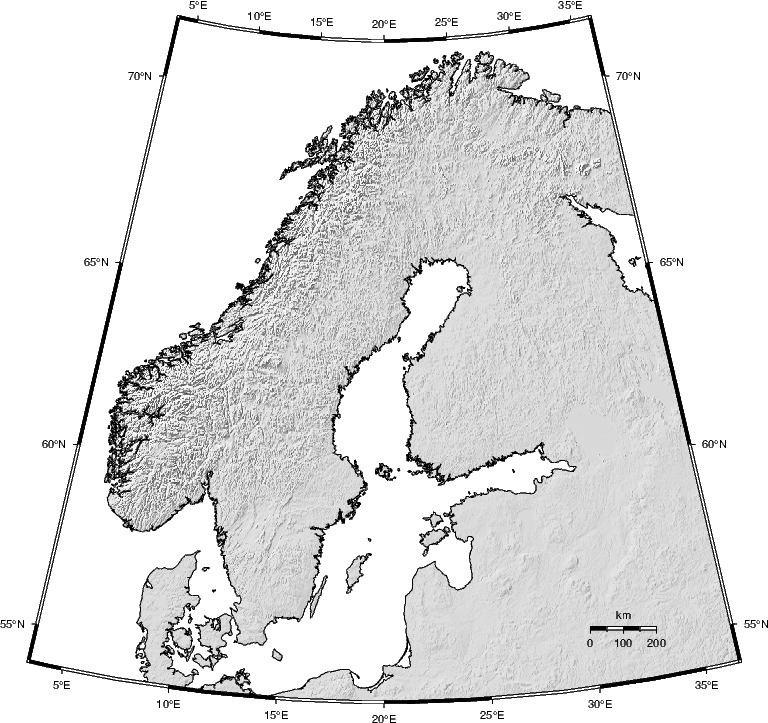

In [4]:
fig.coast(resolution = 'h', 
          shorelines = '1/thinnest,black', 
          water = 'white',
          lakes = 'lightgray', 
          frame = ['x5', 'y5', 'SNEW'],
          area_thresh = ['20/0/1'],
          map_scale = 'f31.5/55.5/56/200+lkm+jt'
         )

fig.show(dpi = dpifig)

Now we add tectonic features like 
* shear zones
* inferred paleo-subduction zones 
* the digitized Tornquist zone

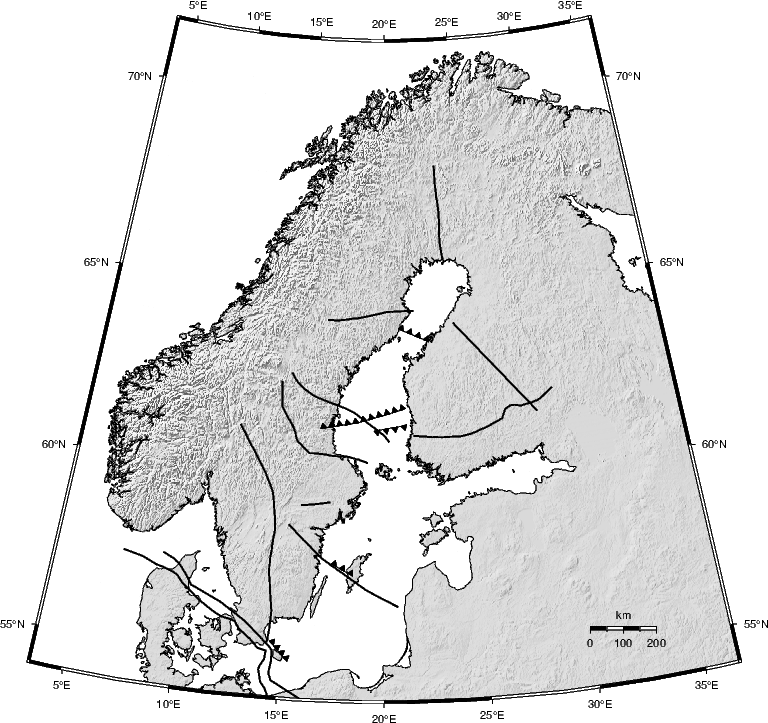

In [5]:
# read in file using pandas
filein2 = 'scan_shear_zones.dat'
namescol2 = ['lon', 'lat', 'name']
datatab2 = pd.read_table(filein2, 
                         sep=r"\s+", 
                         skiprows = 5, 
                         names = namescol2
                        )

# get single names of individual structures to plot
names = list(set(datatab2['name']))
namescl = [x for x in names if str(x) != 'nan']

for name in namescl: # go through the different names 
    tabfilt21 = datatab2[(datatab2['name'] == name)].copy()
    
    tabfilt21['lon'] = tabfilt21['lon'].astype(float) # convert to float
    lons = tabfilt21['lon']
    lats = tabfilt21['lat']
    
    # first distinguish between shear zones and subduction zones
    if name.startswith('Shear'):
        fig.plot(x = lons, 
                 y = lats, 
                 pen = '1p,black'
                )
    else:
        # now distinguish in which direction ((l)eft or (r)ight) sawtooth pattern should be plotted
        if name.endswith('r'):    
            fig.plot(x = lons, 
                     y = lats, 
                     style = 'f0.2/0.15+t+r', 
                     fill = 'black',
                     pen = 'thinnest,black'
                    )
        else:
            fig.plot(x = lons, 
                     y = lats, 
                     style = 'f0.2/0.15+t+l', 
                     fill = 'black',
                     pen = 'thinnest,black'
                    )
                    
# Tornquist Zone, read in file using pandas, we can use the column names from above here 
filein3 = 'scan_STZ.dat'
datatab3 = pd.read_table(filein3, sep=r"\s+", skiprows = 3, names = namescol2)

# get single names of individual structures to plot
names2 = list(set(datatab3['name']))
namescl2 = [x for x in names2 if str(x) != 'nan']  
   
# plot the Tornquist zone 
for name in namescl2:   
    tabfilt31 = datatab3[(datatab3['name'] == name)].copy()
    
    tabfilt31['lon'] = tabfilt31['lon'].astype(float) # convert to float
    lons = tabfilt31['lon']
    lats = tabfilt31['lat']
    
    fig.plot(x = lons, 
             y = lats, 
             pen = '1p,black'
            )            
              
fig.show(dpi = dpifig)

Now we plot first the null stations as green circles using a file in which the plotting order of the indiviudal stations is stored (the file was originally generated in the framework of plotting the individual stereoplots on a map).

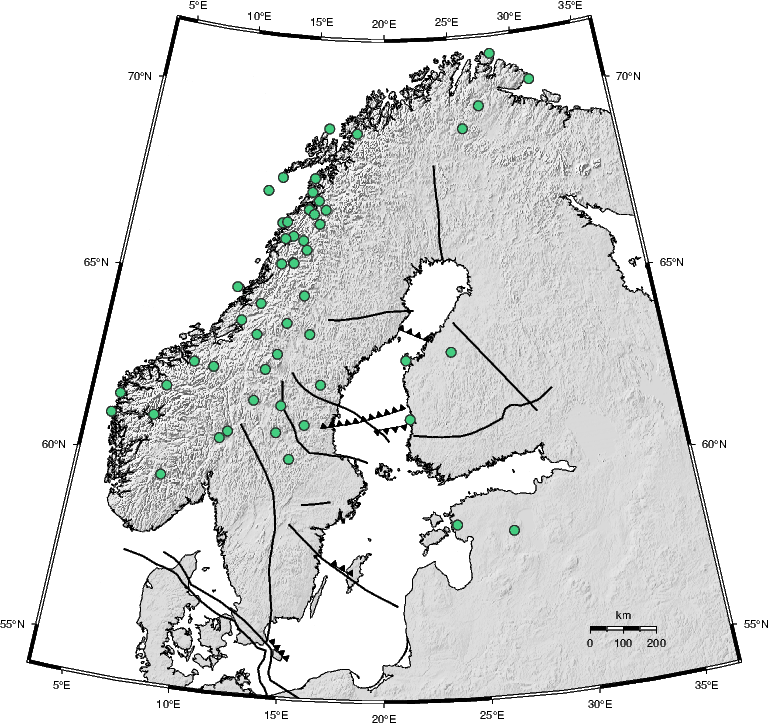

In [6]:
# read in file using pandas
filein = 'results_all_stas_order.dat'
namescol = ['id', 'staname', 'lon', 'lat', 'fname', 'val1', 'val2', 'val3']
datatabori = pd.read_table(filein, 
                           sep=r"\s+", 
                           names = namescol
                          )

# filter out non-null stations
datatab = datatabori[datatabori['val1'] == 0]

dots_fillcol = 'seagreen3'
dots_edgecol = '44/44/44'

fig.plot(x = datatab.lon, 
         y = datatab.lat,
         style = 'c0.25c', 
         fill = dots_fillcol,
         pen = '0.5p,' + dots_edgecol
        )

fig.show(dpi = dpifig)

Do some processing on the input file which contains the splitting results. 

**Please note**: the delay times were previously multiplied by a factor of **60** and thus the values given in the input file are much larger than the typical range of delay times. However, this was done only for plotting reasons.

In [7]:
# read in file using pandas
filein = 'results_split_gf.dat'
namescol = ['lon', 'lat', 'phi', 'thick', 'dt']
datatab = pd.read_table(filein, 
                         sep=r"\s+", 
                         names = namescol
                       )

# rearange column order
cols = datatab.columns.tolist()
cols = cols[0:3] + cols[4:5] + cols[3:4]
datatab = datatab[cols]
datatab.head()

,lon,lat,phi,dt,thick
0,19.9936,60.178,84,36,5.6
1,19.9936,60.178,-77,42,5.6
2,19.9936,60.178,75,24,5.6
3,19.9936,60.178,64,48,5.6
4,19.9936,60.178,88,42,5.6


Now we plot the different splitting measurements as red bars and add black dots to the locations of all stations.

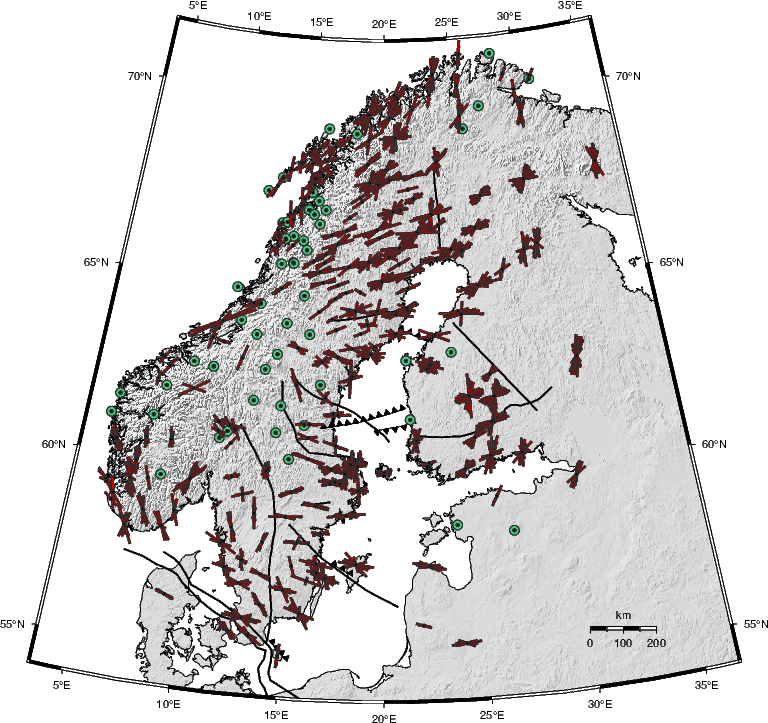

In [8]:
# using rotated rectangles with a red3 fill
bar_fillcol = 'red3'
bar_edgecol = dots_edgecol

fig.plot(datatab, 
         style = 'J', 
         fill = bar_fillcol,
         pen ='0.3p,' + bar_edgecol
        )

# plot black dots on the locations of all stations, for this we use the dataframe created above 
# before filtering (which contains all analyzed stations)
fig.plot(x = datatabori.lon, 
         y = datatabori.lat,
         style = 'c0.08c', 
         fill = 'black',
         pen = '0.5p,' + bar_edgecol
        )

fig.show(dpi = dpifig)

In the next step we build and plot the custom legend:

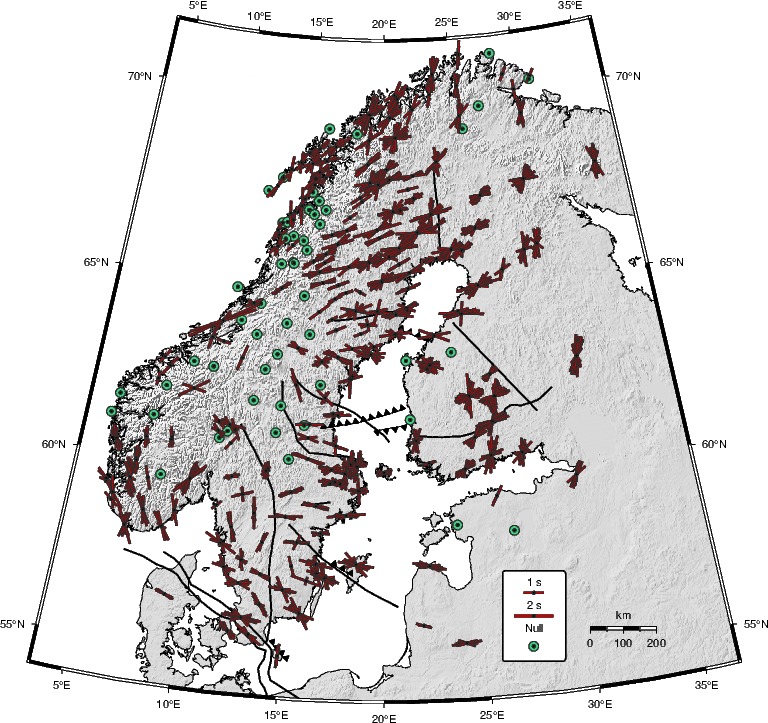

In [9]:
spec_io = io.StringIO(
f"""
G 0.09i
N 3
G -0.25c
H 8 Helvetica  1 s
G -0.03c
S 0.65c j 90,1.5p,0.5c {bar_fillcol} 0.3p,{bar_edgecol}
S 0.12c c 0.08c black 0.5p,{bar_edgecol} -1.3c
H 8 Helvetica  2 s
G -0.03c
S 0.65c j 90,1.5p,1c {bar_fillcol} 0.3p,{bar_edgecol}
S 0.12c c 0.08c black 0.5p,{bar_edgecol} -1.3c
H 8 Helvetica  Null
G 0.15c
S 0.65 c  0.25c {dots_fillcol} 0.5p,{bar_edgecol} -1.3c
S 0.12c c 0.08c black 0.5p,{bar_edgecol} -1.3c
G 0.15c
G 0.02i
"""
)

# generate legend    
fig.legend(spec = spec_io, position = 'x12/1/1.6c/2.3c/BL', box = '+r2p+pblack+gwhite+p0.8p')
    
fig.show(dpi = dpifig)

Next, we plot the area boundaries (in blue color) for which the results are shown in a separate histogram plot (Fig. 5 of the paper).

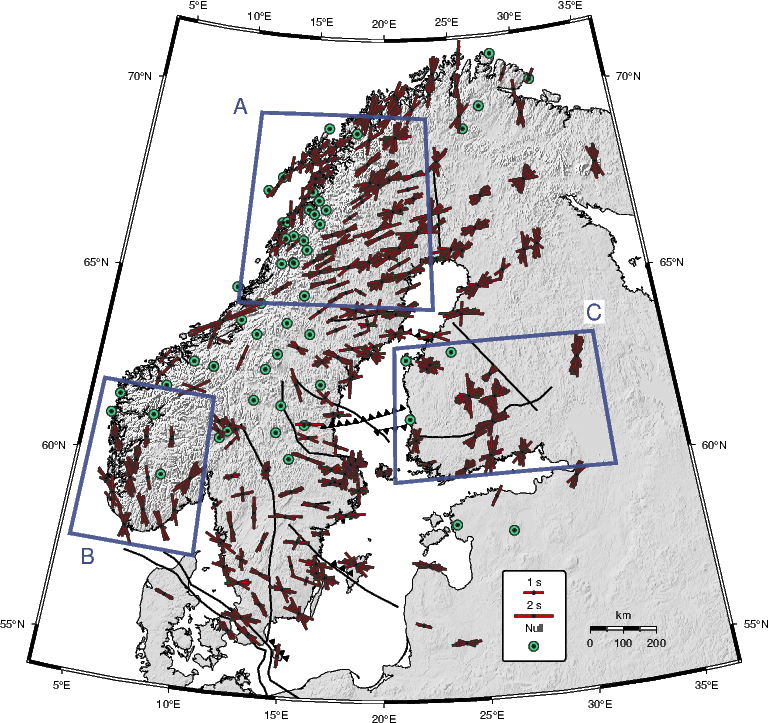

In [10]:
colbounds = '61.6095/76.2448/138.2549'
transpbounds = '10' # transparency level
penbounds = '0.085c'

# south Norway
data = np.array([[4, 57.6],
                [4, 61.9],
                [10.3, 61.9],
                [10.3, 57.6],
                [4, 57.6]]
               )

fig.plot(data = data,
         pen = penbounds + ',' + colbounds,
         transparency = transpbounds
        )  

# south Finland
data = np.array([[20.6, 59.9],
                [20.6, 63.5],
                [32.5, 63.5],
                [32.5, 59.9],
                [20.6, 59.9]]
               )

fig.plot(data = data,
         pen = penbounds + ',' + colbounds,
         transparency = transpbounds
        ) 

# central Norway
data = np.array([[11, 64.5],
                [11, 69.5],
                [23, 69.5],
                [23, 64.5],
                [11, 64.5]]
               )

fig.plot(data = data,
         pen = penbounds + ',' + colbounds,
         transparency = transpbounds
        ) 

# add annotations to boxes
fig.text(y = [69.8, 57.3, 64.3], 
         x = [8.5, 4.5, 32.3], 
         text = ['A','B','C'], 
         font = '16p,Helvetica,' + colbounds, 
         fill = 'white',
         offset = '0.25/-0.25',
         clearance = '0.03i/0.03i'
        )

fig.show(dpi = dpifig)

Now let's build the roseplot to show a summary of all splitting directions. For this, first we only plot the polar coordinate system via `fig.rose()` without any directional data:

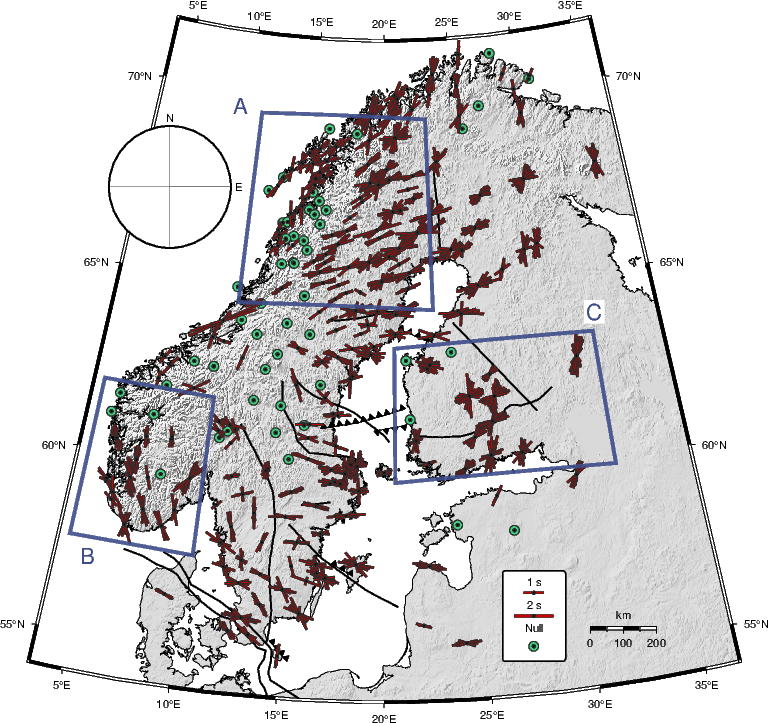

In [11]:
fig.shift_origin(xshift = '2', yshift = '11.5')

with pygmt.config(MAP_ANNOT_OFFSET_PRIMARY = '1.5p'):
    fig.rose(length = 0, # set dummy value 
             azimuth = 0, # set dummy value 
             region = [0, 1, 0, 360],
             diameter = '3.1c',
             frame = ['y90g90', '+gwhite'], # only show azimuthal grid in NESW dirs, no radial grid is plotted
             labels = '-,E,-,N', # just display E and N label
             pen = '0.85p,black'
    )

fig.show(dpi = dpifig)

Now we just add with another `fig.rose()` call the directions of the splitting data atop (this allows the data to overlap the coordinate system) and scale them for our needs:

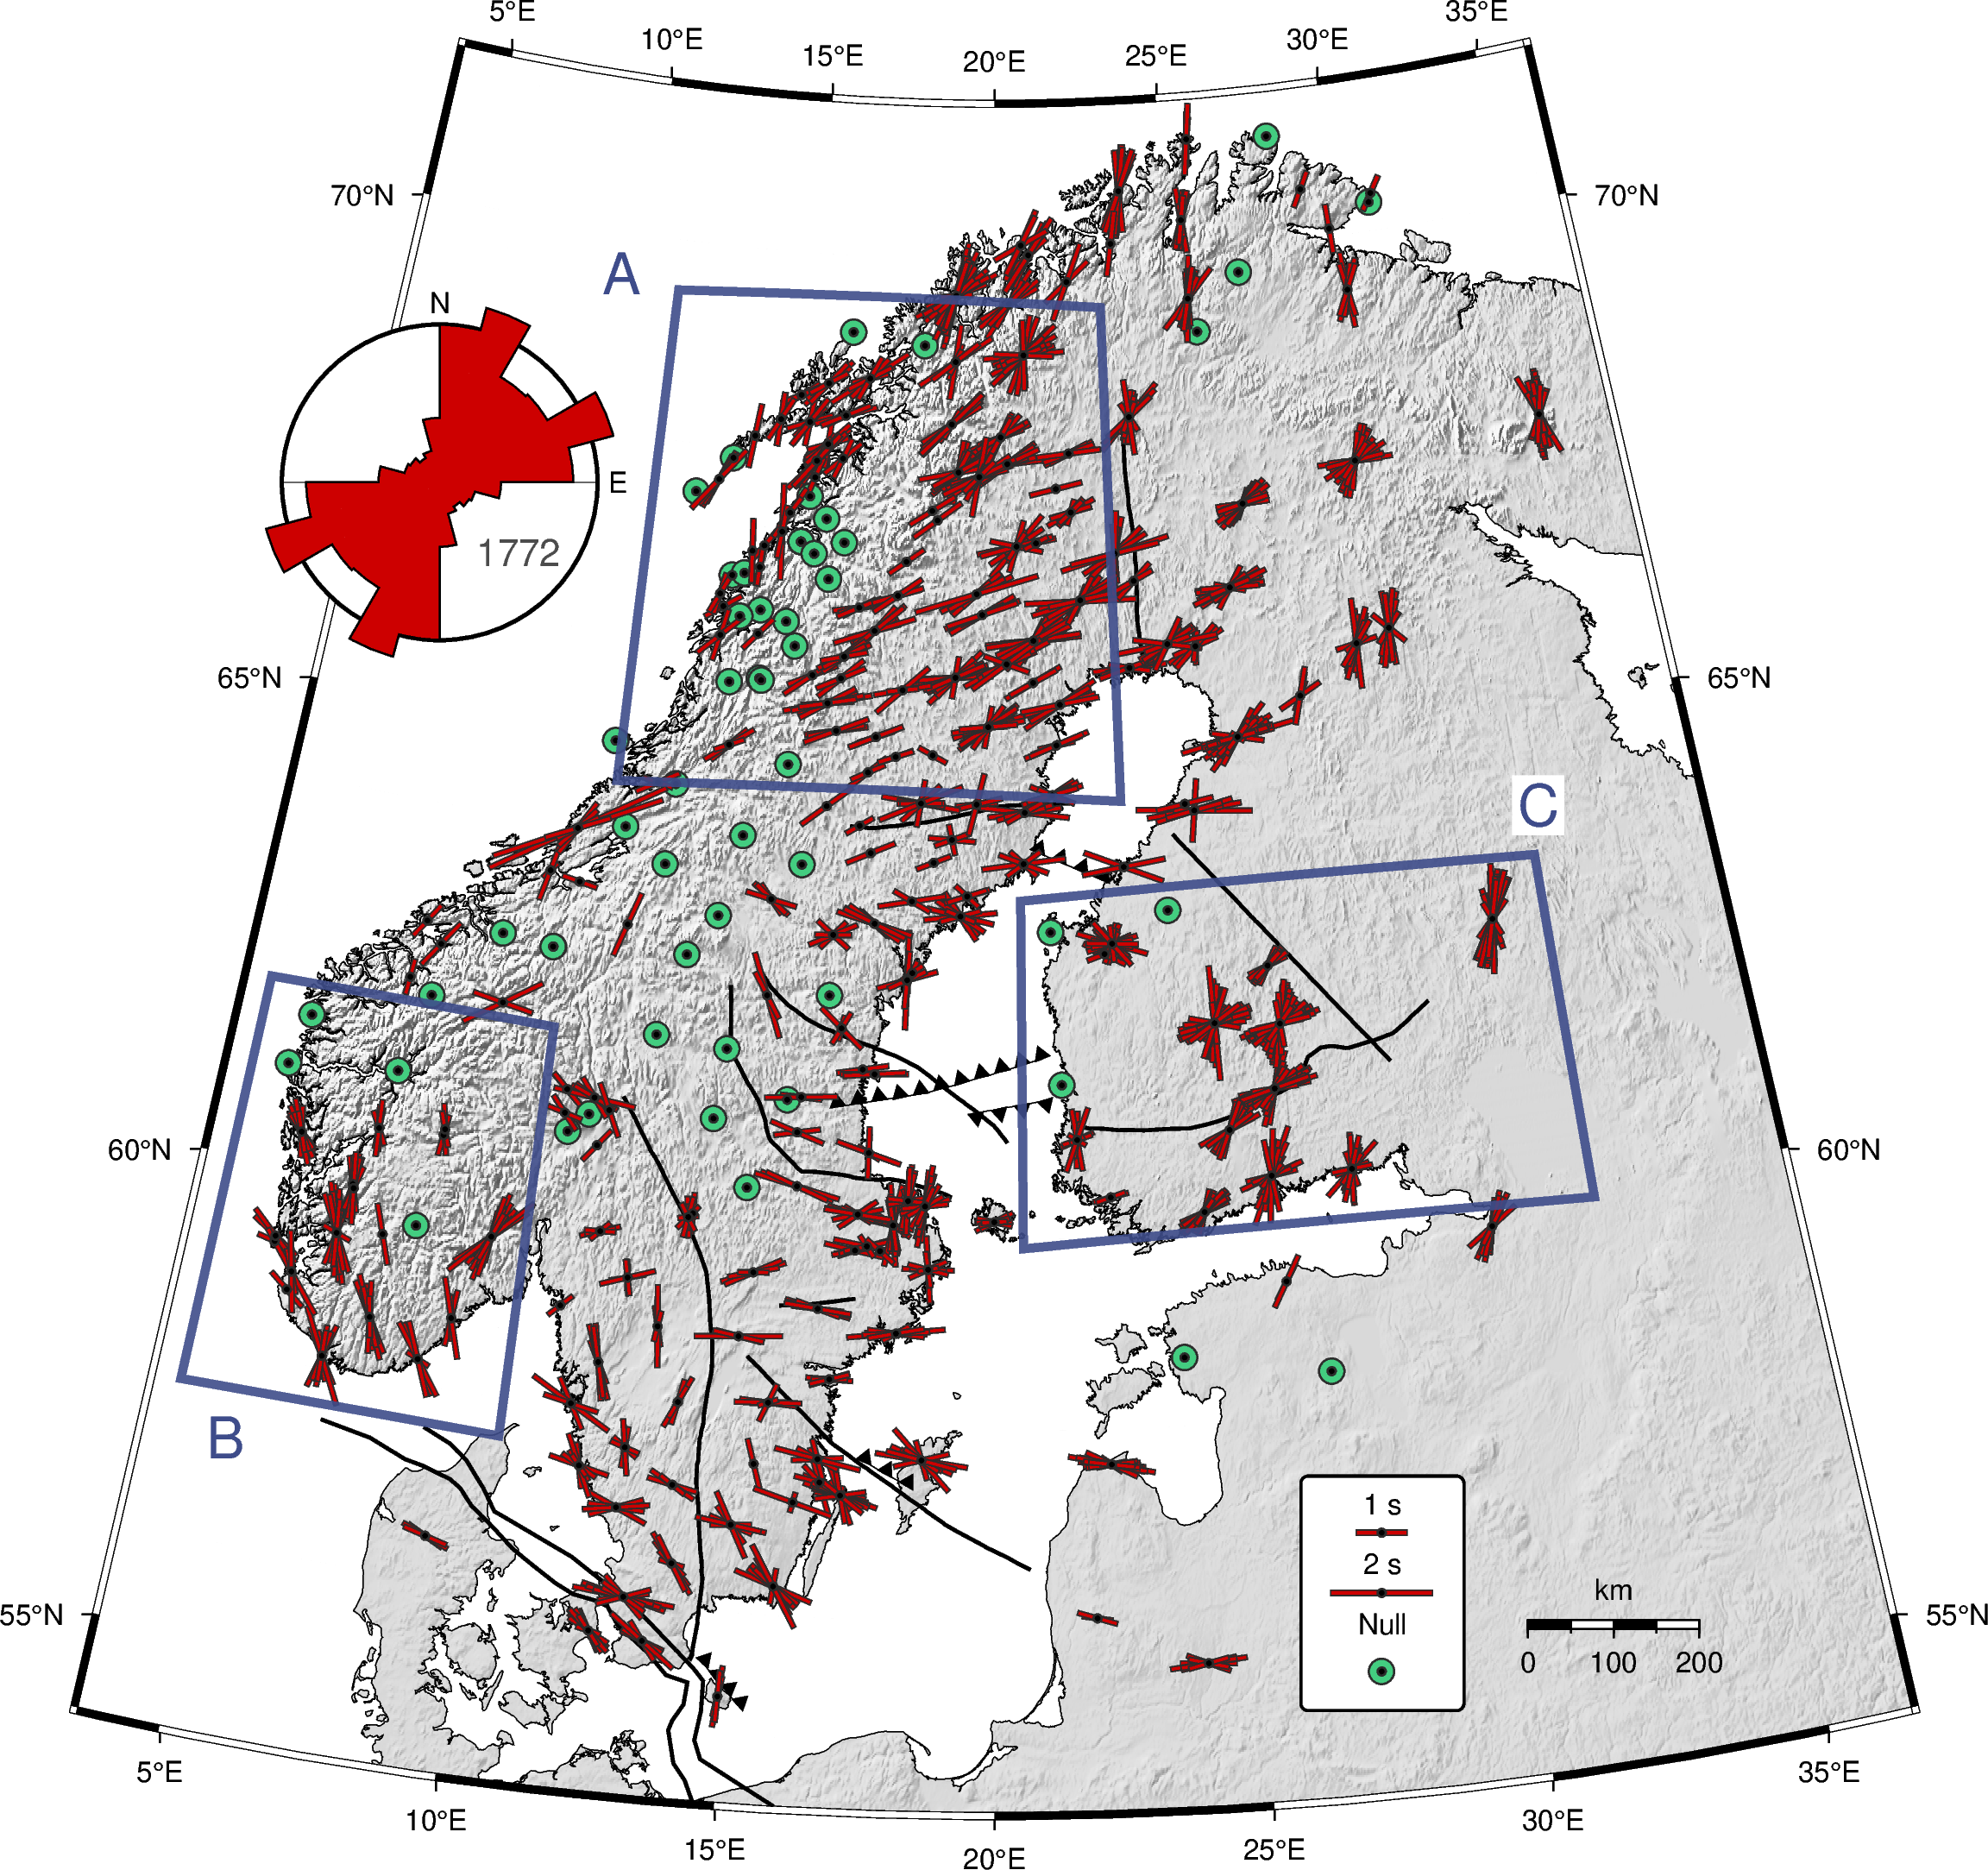

In [12]:
fig.rose(length = datatab.thick, # we just use this data here since it has the same length as the azimuths and constant values
         azimuth = datatab.phi, # that's the important directional data 
         region = [0, 1, 0, 360],
         diameter = '3.1c',
         sector = '15',
         pen = '0.5p,black',
         scale = 0.000736, # scale the data radii down, this is done by trial and error until it fits
         fill = 'red3',
         orientation = True
)

fig.text(x = 0.75,
         y = 100,
         text = len(datatab),
         font = '10.5p, Helvetica',
         transparency = 30
        )

# show final figure in full resolution
fig.show()

Save the figure in png format.

In [13]:
fig.savefig('PLOT_fig4.png', dpi = 300)